In [1]:
import pandas as pd

file_path = "../data/raw/ec_oil/Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Prices with taxes', 'Prices wo taxes', 'Consumption', 'VAT', 'Excise duties', 'Excise duties - components', 'Other Indirect Taxes']


In [2]:
raw_fuel_df = pd.read_excel(
    file_path,
    sheet_name="Prices with taxes",
    header=None
)

print("Shape:", raw_fuel_df.shape)

selected_cols = [0, 3, 10, 32, 55, 189]

display(
    raw_fuel_df.iloc[:8, selected_cols]
)

Shape: (1113, 226)


,0,3,10,32,55,189
0,Consumer prices of petroleum products inclusiv...,EU_price_with_tax_diesel,EUR_price_with_tax_diesel,BG_price_with_tax_diesel,DE_price_with_tax_diesel,RO_price_with_tax_diesel
1,NaN,Gas oil automobile Automotive gas oil Dieselkr...,Gas oil automobile Automotive gas oil Dieselkr...,Gas oil automobile Automotive gas oil Dieselkr...,Gas oil automobile Automotive gas oil Dieselkr...,Gas oil automobile Automotive gas oil Dieselkr...
2,Date,1000 l,1000 l,1000 l,1000 l,1000 l
3,2026-09-21 00:00:00,2226.443515,2262.141401,1915.6,2457,2092.639657
4,2026-09-14 00:00:00,2158.736194,2190.665873,1856.3,2426,1999.69373
5,2026-09-07 00:00:00,2108.412782,2136.647086,1815.5,2328,1941.508787
6,2026-08-31 00:00:00,2039.146962,2098.362911,1812.9,2232,1937.902278
7,2026-08-24 00:00:00,2063.366061,2118.547142,1798.4,2286,1939.770303


In [3]:
diesel_df = raw_fuel_df.iloc[
    3:,
    [0, 3, 32, 55, 189]
].copy()

diesel_df.columns = [
    "date",
    "EU",
    "BG",
    "DE",
    "RO"
]

diesel_df["date"] = pd.to_datetime(
    diesel_df["date"],
    errors="coerce"
)

diesel_df = diesel_df.dropna(
    subset=["date"]
).copy()

for geo in ["EU", "BG", "DE", "RO"]:
    diesel_df[geo] = pd.to_numeric(
        diesel_df[geo],
        errors="coerce"
    )

display(diesel_df.head())

print("Shape:", diesel_df.shape)

,date,EU,BG,DE,RO
3,2026-09-21,2226.443515,1915.6,2457.0,2092.639657
4,2026-09-14,2158.736194,1856.3,2426.0,1999.693730
5,2026-09-07,2108.412782,1815.5,2328.0,1941.508787
6,2026-08-31,2039.146962,1812.9,2232.0,1937.902278
7,2026-08-24,2063.366061,1798.4,2286.0,1939.770303


Shape: (1085, 5)


In [4]:
print(diesel_df.dtypes)

print("Duplicate dates:", diesel_df["date"].duplicated().sum())

print("\nMissing values:")
print(diesel_df.isna().sum())

for geo in ["EU", "BG", "DE", "RO"]:
    valid_data = diesel_df.dropna(subset=[geo])

    print(
        geo,
        "| observations:", len(valid_data),
        "| first:", valid_data["date"].min().date(),
        "| last:", valid_data["date"].max().date()
    )

date    datetime64[us]
EU             float64
BG             float64
DE             float64
RO             float64
dtype: object
Duplicate dates: 0

Missing values:
date      0
EU        0
BG      148
DE        0
RO      147
dtype: int64
EU | observations: 1085 | first: 2005-01-03 | last: 2026-09-21
BG | observations: 937 | first: 2008-01-07 | last: 2026-09-21
DE | observations: 1085 | first: 2005-01-03 | last: 2026-09-21
RO | observations: 938 | first: 2008-01-07 | last: 2026-09-21


In [5]:
comparison_df = diesel_df[
    diesel_df["date"] >= "2008-01-07"
].copy()

print("Shape:", comparison_df.shape)

print("\nMissing values in comparison period:")
print(comparison_df.isna().sum())

print("\nBG missing dates:")
print(
    comparison_df.loc[
        comparison_df["BG"].isna(),
        "date"
    ]
)

Shape: (938, 5)

Missing values in comparison period:
date    0
EU      0
BG      1
DE      0
RO      0
dtype: int64

BG missing dates:
150   2023-11-27
Name: date, dtype: datetime64[us]


In [6]:
monthly_diesel_df = (
    comparison_df
    .set_index("date")[["EU", "BG", "DE", "RO"]]
    .resample("MS")
    .mean()
    .reset_index()
)

display(monthly_diesel_df.head())

print("Shape:", monthly_diesel_df.shape)
print("First month:", monthly_diesel_df["date"].min().date())
print("Last month:", monthly_diesel_df["date"].max().date())

print("\nMissing monthly values:")
print(monthly_diesel_df.isna().sum())

,date,EU,BG,DE,RO
0,2008-01-01,1200.895274,997.2900,1251.9375,991.4425
1,2008-02-01,1207.871916,1014.3675,1263.8750,1020.4400
2,2008-03-01,1256.656304,1072.6550,1322.1250,1047.5150
3,2008-04-01,1285.342729,1102.8750,1331.1875,1121.6025
4,2008-05-01,1374.801370,1201.3500,1427.6875,1183.2000


Shape: (225, 5)
First month: 2008-01-01
Last month: 2026-09-01

Missing monthly values:
date    0
EU      0
BG      0
DE      0
RO      0
dtype: int64


In [7]:
monthly_diesel_long_df = monthly_diesel_df.melt(
    id_vars="date",
    value_vars=["EU", "BG", "DE", "RO"],
    var_name="geo",
    value_name="diesel_price_per_1000l"
)

monthly_diesel_long_df = monthly_diesel_long_df.rename(
    columns={"date": "month"}
)

monthly_diesel_long_df = monthly_diesel_long_df.sort_values(
    ["month", "geo"]
).reset_index(drop=True)

display(monthly_diesel_long_df.head(8))

print("Rows:", len(monthly_diesel_long_df))

,month,geo,diesel_price_per_1000l
0,2008-01-01,BG,997.290000
1,2008-01-01,DE,1251.937500
2,2008-01-01,EU,1200.895274
3,2008-01-01,RO,991.442500
4,2008-02-01,BG,1014.367500
5,2008-02-01,DE,1263.875000
6,2008-02-01,EU,1207.871916
7,2008-02-01,RO,1020.440000


Rows: 900


In [8]:
print(monthly_diesel_long_df.dtypes)

print("Rows:", len(monthly_diesel_long_df))

print(
    "Missing values:",
    monthly_diesel_long_df.isna().sum().to_dict()
)

print(
    "Duplicate month-geo rows:",
    monthly_diesel_long_df[
        ["month", "geo"]
    ].duplicated().sum()
)

print(
    "First month:",
    monthly_diesel_long_df["month"].min().date()
)

print(
    "Last month:",
    monthly_diesel_long_df["month"].max().date()
)

print(
    "Geographies:",
    sorted(monthly_diesel_long_df["geo"].unique())
)

month                     datetime64[us]
geo                                  str
diesel_price_per_1000l           float64
dtype: object
Rows: 900
Missing values: {'month': 0, 'geo': 0, 'diesel_price_per_1000l': 0}
Duplicate month-geo rows: 0
First month: 2008-01-01
Last month: 2026-09-01
Geographies: ['BG', 'DE', 'EU', 'RO']


In [9]:
db_rows = list(
    monthly_diesel_long_df.itertuples(
        index=False,
        name=None
    )
)

print("Rows prepared:", len(db_rows))
print("First 4 rows:")

for row in db_rows[:4]:
    print(row)

Rows prepared: 900
First 4 rows:
(Timestamp('2008-01-01 00:00:00'), 'BG', 997.29)
(Timestamp('2008-01-01 00:00:00'), 'DE', 1251.9375)
(Timestamp('2008-01-01 00:00:00'), 'EU', 1200.8952744472665)
(Timestamp('2008-01-01 00:00:00'), 'RO', 991.4425)


In [10]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [11]:
from src.db import get_connection

connection = get_connection()
cursor = connection.cursor()

insert_sql = """
INSERT INTO diesel_prices (
    month,
    geo,
    diesel_price_per_1000l
)
VALUES (?, ?, ?)
ON DUPLICATE KEY UPDATE
    diesel_price_per_1000l = VALUES(diesel_price_per_1000l);
"""

cursor.executemany(
    insert_sql,
    db_rows
)

connection.commit()

print("Inserted/updated rows:", len(db_rows))

cursor.close()
connection.close()

Inserted/updated rows: 900


In [12]:
connection = get_connection()
cursor = connection.cursor()

cursor.execute("""
SELECT
    COUNT(*),
    MIN(month),
    MAX(month)
FROM diesel_prices;
""")

result = cursor.fetchone()

print("Rows:", result[0])
print("First month:", result[1])
print("Last month:", result[2])

cursor.close()
connection.close()

Rows: 900
First month: 2008-01-01
Last month: 2026-09-01


In [13]:
from src.fuel_pipeline import load_raw_fuel_data

test_raw_fuel_df = load_raw_fuel_data()

print("Shape:", test_raw_fuel_df.shape)

Shape: (1113, 226)


In [14]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

weekly_df = fuel_pipeline.build_weekly_diesel_dataframe(
    test_raw_fuel_df
)

display(weekly_df.head())

print("Shape:", weekly_df.shape)

,date,EU,BG,DE,RO
3,2026-09-21,2226.443515,1915.6,2457.0,2092.639657
4,2026-09-14,2158.736194,1856.3,2426.0,1999.693730
5,2026-09-07,2108.412782,1815.5,2328.0,1941.508787
6,2026-08-31,2039.146962,1812.9,2232.0,1937.902278
7,2026-08-24,2063.366061,1798.4,2286.0,1939.770303


Shape: (1085, 5)


In [15]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

monthly_df = fuel_pipeline.build_monthly_diesel_dataframe(
    weekly_df
)

display(monthly_df.head())

print("Shape:", monthly_df.shape)
print("First month:", monthly_df["date"].min().date())
print("Last month:", monthly_df["date"].max().date())

,date,EU,BG,DE,RO
0,2008-01-01,1200.895274,997.2900,1251.9375,991.4425
1,2008-02-01,1207.871916,1014.3675,1263.8750,1020.4400
2,2008-03-01,1256.656304,1072.6550,1322.1250,1047.5150
3,2008-04-01,1285.342729,1102.8750,1331.1875,1121.6025
4,2008-05-01,1374.801370,1201.3500,1427.6875,1183.2000


Shape: (225, 5)
First month: 2008-01-01
Last month: 2026-09-01


In [16]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

long_df = fuel_pipeline.build_long_diesel_dataframe(
    monthly_df
)

display(long_df.head(8))

print("Shape:", long_df.shape)
print("Rows:", len(long_df))

,month,geo,diesel_price_per_1000l
0,2008-01-01,BG,997.290000
1,2008-01-01,DE,1251.937500
2,2008-01-01,EU,1200.895274
3,2008-01-01,RO,991.442500
4,2008-02-01,BG,1014.367500
5,2008-02-01,DE,1263.875000
6,2008-02-01,EU,1207.871916
7,2008-02-01,RO,1020.440000


Shape: (900, 3)
Rows: 900


In [17]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

db_rows_test = fuel_pipeline.prepare_diesel_db_rows(
    long_df
)

print("Rows prepared:", len(db_rows_test))
print("First 4 rows:")

for row in db_rows_test[:4]:
    print(row)

Rows prepared: 900
First 4 rows:
(Timestamp('2008-01-01 00:00:00'), 'BG', 997.29)
(Timestamp('2008-01-01 00:00:00'), 'DE', 1251.9375)
(Timestamp('2008-01-01 00:00:00'), 'EU', 1200.8952744472665)
(Timestamp('2008-01-01 00:00:00'), 'RO', 991.4425)


In [18]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

fuel_pipeline.load_diesel_to_database(
    db_rows_test
)

print("Database load completed.")

Database load completed.


In [19]:
connection = get_connection()
cursor = connection.cursor()

cursor.execute("""
SELECT COUNT(*)
FROM diesel_prices;
""")

print("Rows in database:", cursor.fetchone()[0])

cursor.close()
connection.close()

Rows in database: 900


In [20]:
import importlib
import src.fuel_pipeline as fuel_pipeline

importlib.reload(fuel_pipeline)

rows_processed = fuel_pipeline.run_fuel_pipeline()

print("Fuel pipeline completed:", rows_processed, "rows")

Fuel pipeline completed: 900 rows


In [21]:
from src.db import get_connection

lag3_summary_sql = """
WITH diesel_yoy AS (
    SELECT
        month,
        geo,
        (
            (
                diesel_price_per_1000l
                - LAG(diesel_price_per_1000l, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                )
            )
            /
            NULLIF(
                LAG(diesel_price_per_1000l, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                ),
                0
            )
        ) * 100 AS diesel_yoy_pct
    FROM diesel_prices
    WHERE geo IN ('BG', 'DE', 'RO')
),

diesel_lags AS (
    SELECT
        month,
        geo,
        LAG(diesel_yoy_pct, 3) OVER (
            PARTITION BY geo
            ORDER BY month
        ) AS diesel_yoy_lag3
    FROM diesel_yoy
),

food_yoy AS (
    SELECT
        month,
        geo,
        (
            (
                hicp_index
                - LAG(hicp_index, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                )
            )
            /
            NULLIF(
                LAG(hicp_index, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                ),
                0
            )
        ) * 100 AS food_hicp_yoy_pct
    FROM hicp_food_index
    WHERE geo IN ('BG', 'DE', 'RO')
),

joined_data AS (
    SELECT
        d.month,
        d.geo,
        d.diesel_yoy_lag3,
        f.food_hicp_yoy_pct
    FROM diesel_lags AS d
    INNER JOIN food_yoy AS f
        ON d.month = f.month
        AND d.geo = f.geo
    WHERE d.month >= '2023-01-01'
)

SELECT
    geo,

    COUNT(
        CASE
            WHEN diesel_yoy_lag3 > 0
            THEN 1
        END
    ) AS diesel_up_observations,

    COUNT(
        CASE
            WHEN diesel_yoy_lag3 < 0
            THEN 1
        END
    ) AS diesel_down_observations,

    ROUND(
        AVG(
            CASE
                WHEN diesel_yoy_lag3 > 0
                THEN food_hicp_yoy_pct
            END
        ),
        2
    ) AS avg_food_when_diesel_up,

    ROUND(
        AVG(
            CASE
                WHEN diesel_yoy_lag3 < 0
                THEN food_hicp_yoy_pct
            END
        ),
        2
    ) AS avg_food_when_diesel_down,

    ROUND(
        AVG(
            CASE
                WHEN diesel_yoy_lag3 > 0
                THEN food_hicp_yoy_pct
            END
        )
        -
        AVG(
            CASE
                WHEN diesel_yoy_lag3 < 0
                THEN food_hicp_yoy_pct
            END
        ),
        2
    ) AS difference_pp

FROM joined_data
GROUP BY geo
ORDER BY geo;
"""

connection = get_connection()
cursor = connection.cursor()

cursor.execute(lag3_summary_sql)

rows = cursor.fetchall()
columns = [column[0] for column in cursor.description]

lag3_summary_df = pd.DataFrame(rows, columns=columns)

cursor.close()
connection.close()

display(lag3_summary_df)

,geo,diesel_up_observations,diesel_down_observations,avg_food_when_diesel_up,avg_food_when_diesel_down,difference_pp
0,BG,12,32,9.77,5.88,3.89
1,DE,18,26,6.46,4.22,2.24
2,RO,27,17,8.30,7.23,1.07


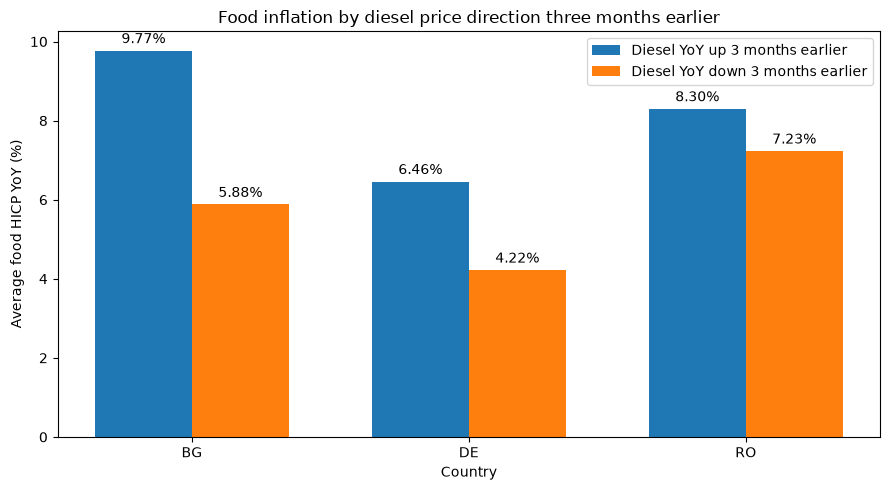

In [22]:
import matplotlib.pyplot as plt

lag3_summary_df["avg_food_when_diesel_up"] = (
    lag3_summary_df["avg_food_when_diesel_up"].astype(float)
)

lag3_summary_df["avg_food_when_diesel_down"] = (
    lag3_summary_df["avg_food_when_diesel_down"].astype(float)
)

x = range(len(lag3_summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_up = ax.bar(
    [i - width / 2 for i in x],
    lag3_summary_df["avg_food_when_diesel_up"],
    width=width,
    label="Diesel YoY up 3 months earlier"
)

bars_down = ax.bar(
    [i + width / 2 for i in x],
    lag3_summary_df["avg_food_when_diesel_down"],
    width=width,
    label="Diesel YoY down 3 months earlier"
)

ax.set_xticks(list(x))
ax.set_xticklabels(lag3_summary_df["geo"])

ax.set_xlabel("Country")
ax.set_ylabel("Average food HICP YoY (%)")
ax.set_title(
    "Food inflation by diesel price direction three months earlier"
)

ax.bar_label(bars_up, fmt="%.2f%%", padding=3)
ax.bar_label(bars_down, fmt="%.2f%%", padding=3)

ax.legend()

plt.tight_layout()

from pathlib import Path

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

figure_path = FIGURES_DIR / "diesel_food_lag3_comparison.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

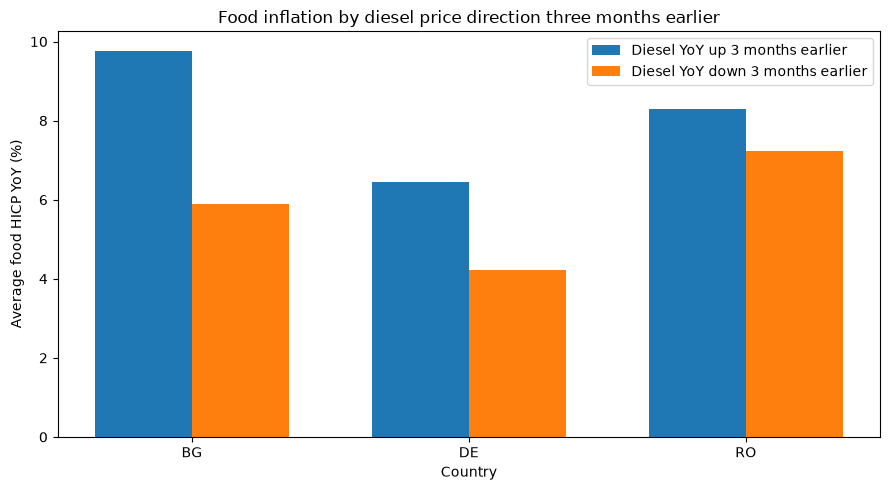

In [23]:
import matplotlib.pyplot as plt

lag3_summary_df["avg_food_when_diesel_up"] = (
    lag3_summary_df["avg_food_when_diesel_up"].astype(float)
)

lag3_summary_df["avg_food_when_diesel_down"] = (
    lag3_summary_df["avg_food_when_diesel_down"].astype(float)
)

x = range(len(lag3_summary_df))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    [i - width / 2 for i in x],
    lag3_summary_df["avg_food_when_diesel_up"],
    width=width,
    label="Diesel YoY up 3 months earlier"
)

plt.bar(
    [i + width / 2 for i in x],
    lag3_summary_df["avg_food_when_diesel_down"],
    width=width,
    label="Diesel YoY down 3 months earlier"
)

plt.xticks(x, lag3_summary_df["geo"])

plt.xlabel("Country")
plt.ylabel("Average food HICP YoY (%)")
plt.title(
    "Food inflation by diesel price direction three months earlier"
)

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
from pathlib import Path

print(Path.cwd())

c:\Users\User\Desktop\Python Essentials\european_food_price_monitor\notebooks


In [25]:
from pathlib import Path

figure_path = Path("../outputs/figures/diesel_food_lag3_comparison.png")

print("Exists:", figure_path.exists())
print("Path:", figure_path.resolve())

Exists: True
Path: C:\Users\User\Desktop\Python Essentials\european_food_price_monitor\outputs\figures\diesel_food_lag3_comparison.png


In [26]:
diesel_food_timeseries_sql = """
WITH diesel_yoy AS (
    SELECT
        month,
        geo,
        (
            (
                diesel_price_per_1000l
                - LAG(diesel_price_per_1000l, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                )
            )
            /
            NULLIF(
                LAG(diesel_price_per_1000l, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                ),
                0
            )
        ) * 100 AS diesel_yoy_pct
    FROM diesel_prices
    WHERE geo IN ('BG', 'DE', 'RO')
),

diesel_lags AS (
    SELECT
        month,
        geo,
        diesel_yoy_pct,
        LAG(diesel_yoy_pct, 3) OVER (
            PARTITION BY geo
            ORDER BY month
        ) AS diesel_yoy_lag3
    FROM diesel_yoy
),

food_yoy AS (
    SELECT
        month,
        geo,
        (
            (
                hicp_index
                - LAG(hicp_index, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                )
            )
            /
            NULLIF(
                LAG(hicp_index, 12) OVER (
                    PARTITION BY geo
                    ORDER BY month
                ),
                0
            )
        ) * 100 AS food_hicp_yoy_pct
    FROM hicp_food_index
    WHERE geo IN ('BG', 'DE', 'RO')
)

SELECT
    d.month,
    d.geo,
    d.diesel_yoy_pct,
    d.diesel_yoy_lag3,
    f.food_hicp_yoy_pct
FROM diesel_lags AS d
INNER JOIN food_yoy AS f
    ON d.month = f.month
    AND d.geo = f.geo
WHERE d.month >= '2023-01-01'
ORDER BY d.geo, d.month;
"""

connection = get_connection()
cursor = connection.cursor()

cursor.execute(diesel_food_timeseries_sql)

rows = cursor.fetchall()
columns = [column[0] for column in cursor.description]

diesel_food_timeseries_df = pd.DataFrame(
    rows,
    columns=columns
)

cursor.close()
connection.close()

display(diesel_food_timeseries_df.head(10))

print("Rows:", len(diesel_food_timeseries_df))

,month,geo,diesel_yoy_pct,diesel_yoy_lag3,food_hicp_yoy_pct
0,2023-01-01,BG,19.02641330,40.57222586,25.19363470
1,2023-02-01,BG,11.57328616,35.55478433,24.21885660
2,2023-03-01,BG,-3.44097188,27.16820108,21.54294032
3,2023-04-01,BG,-11.99436975,19.02641330,16.78517014
4,2023-05-01,BG,-22.39892379,11.57328616,14.90791439
5,2023-06-01,BG,-28.14189445,-3.44097188,13.83756975
6,2023-07-01,BG,-29.72885119,-11.99436975,13.63129875
7,2023-08-01,BG,-19.23463673,-22.39892379,12.46483180
8,2023-09-01,BG,-12.66834217,-28.14189445,10.84583083
9,2023-10-01,BG,-11.56003694,-29.72885119,7.85990395


Rows: 132


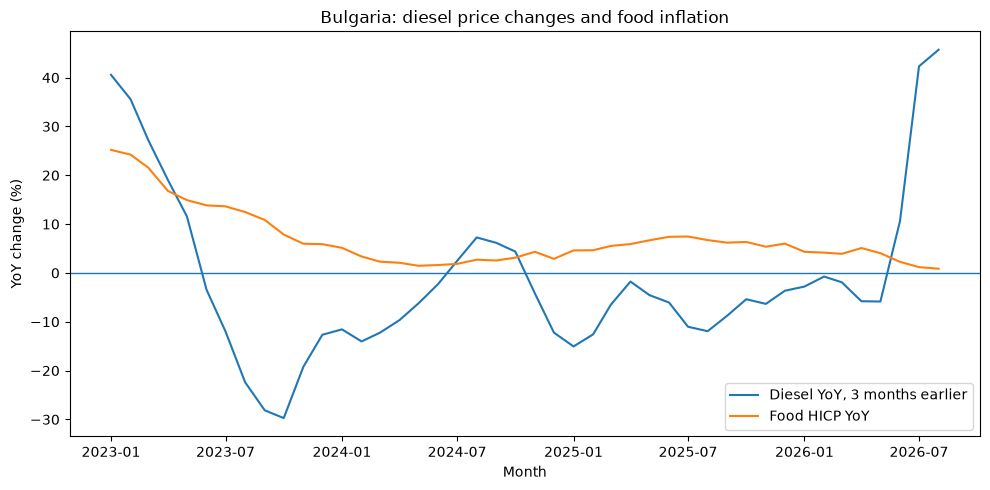

In [27]:
diesel_food_timeseries_df["month"] = pd.to_datetime(
    diesel_food_timeseries_df["month"]
)

diesel_food_timeseries_df["diesel_yoy_lag3"] = (
    diesel_food_timeseries_df["diesel_yoy_lag3"].astype(float)
)

diesel_food_timeseries_df["food_hicp_yoy_pct"] = (
    diesel_food_timeseries_df["food_hicp_yoy_pct"].astype(float)
)

bg_timeseries_df = diesel_food_timeseries_df[
    diesel_food_timeseries_df["geo"] == "BG"
].copy()

plt.figure(figsize=(10, 5))

plt.plot(
    bg_timeseries_df["month"],
    bg_timeseries_df["diesel_yoy_lag3"],
    label="Diesel YoY, 3 months earlier"
)

plt.plot(
    bg_timeseries_df["month"],
    bg_timeseries_df["food_hicp_yoy_pct"],
    label="Food HICP YoY"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Month")
plt.ylabel("YoY change (%)")
plt.title(
    "Bulgaria: diesel price changes and food inflation"
)

plt.legend()
plt.tight_layout()
plt.show()

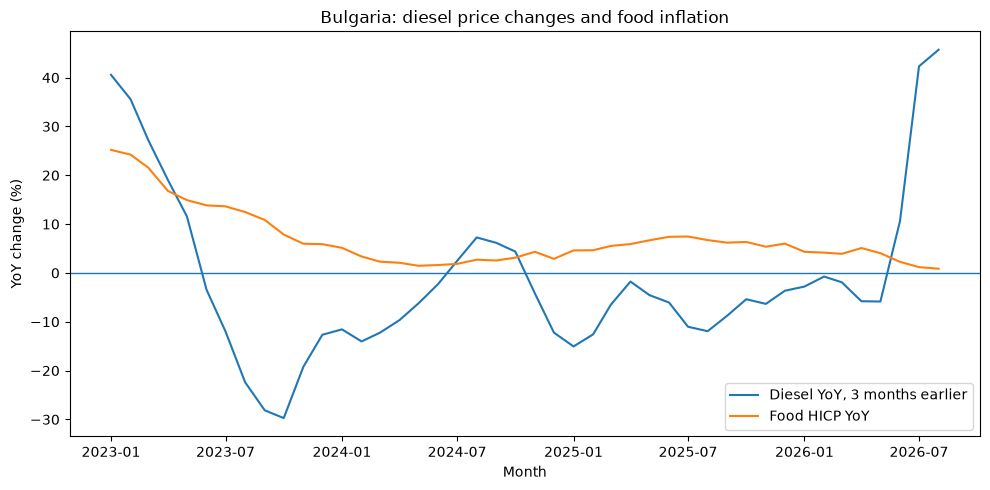

Saved to: C:\Users\User\Desktop\Python Essentials\european_food_price_monitor\outputs\figures\bg_diesel_food_timeseries.png


In [28]:
diesel_food_timeseries_df["month"] = pd.to_datetime(
    diesel_food_timeseries_df["month"]
)

diesel_food_timeseries_df["diesel_yoy_lag3"] = (
    diesel_food_timeseries_df["diesel_yoy_lag3"].astype(float)
)

diesel_food_timeseries_df["food_hicp_yoy_pct"] = (
    diesel_food_timeseries_df["food_hicp_yoy_pct"].astype(float)
)

bg_timeseries_df = diesel_food_timeseries_df[
    diesel_food_timeseries_df["geo"] == "BG"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    bg_timeseries_df["month"],
    bg_timeseries_df["diesel_yoy_lag3"],
    label="Diesel YoY, 3 months earlier"
)

ax.plot(
    bg_timeseries_df["month"],
    bg_timeseries_df["food_hicp_yoy_pct"],
    label="Food HICP YoY"
)

ax.axhline(0, linewidth=1)

ax.set_xlabel("Month")
ax.set_ylabel("YoY change (%)")
ax.set_title(
    "Bulgaria: diesel price changes and food inflation"
)

ax.legend()

plt.tight_layout()

figure_path = FIGURES_DIR / "bg_diesel_food_timeseries.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", figure_path.resolve())

In [29]:
def plot_diesel_food_timeseries(geo):
    country_df = diesel_food_timeseries_df[
        diesel_food_timeseries_df["geo"] == geo
    ].copy()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        country_df["month"],
        country_df["diesel_yoy_lag3"],
        label="Diesel YoY, 3 months earlier"
    )

    ax.plot(
        country_df["month"],
        country_df["food_hicp_yoy_pct"],
        label="Food HICP YoY"
    )

    ax.axhline(0, linewidth=1)

    ax.set_xlabel("Month")
    ax.set_ylabel("YoY change (%)")
    ax.set_title(
        f"{geo}: diesel price changes and food inflation"
    )

    ax.legend()
    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"{geo.lower()}_diesel_food_timeseries.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved to:", figure_path.resolve())

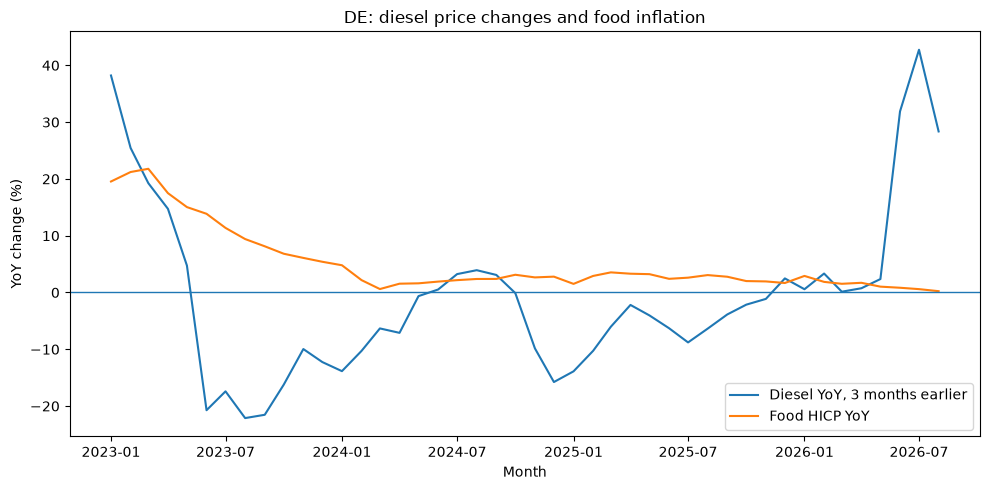

Saved to: C:\Users\User\Desktop\Python Essentials\european_food_price_monitor\outputs\figures\de_diesel_food_timeseries.png


In [30]:
plot_diesel_food_timeseries("DE")

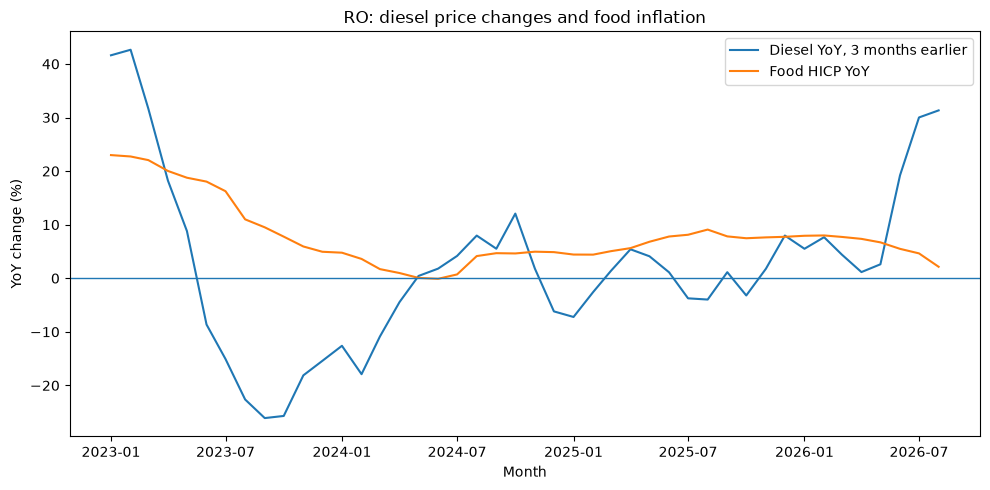

Saved to: C:\Users\User\Desktop\Python Essentials\european_food_price_monitor\outputs\figures\ro_diesel_food_timeseries.png


In [31]:
plot_diesel_food_timeseries("RO")

In [32]:
figure_files = [
    "diesel_food_lag3_comparison.png",
    "bg_diesel_food_timeseries.png",
    "de_diesel_food_timeseries.png",
    "ro_diesel_food_timeseries.png",
]

for filename in figure_files:
    path = FIGURES_DIR / filename
    print(filename, "->", path.exists())

diesel_food_lag3_comparison.png -> True
bg_diesel_food_timeseries.png -> True
de_diesel_food_timeseries.png -> True
ro_diesel_food_timeseries.png -> True


## Interpretation

The exploratory analysis compares year-over-year changes in monthly diesel prices with year-over-year food HICP inflation for Bulgaria, Germany and Romania.

Among the tested lags from 0 to 3 months, the strongest positive linear association was observed at a three-month lag:

- Bulgaria: 0.331
- Germany: 0.213
- Romania: 0.378

The conditional comparison also shows that average food HICP inflation was higher in months preceded three months earlier by positive diesel-price YoY growth:

| Country | Diesel up | Diesel down | Difference |
|---|---:|---:|---:|
| Bulgaria | 9.77% | 5.88% | +3.89 pp |
| Germany | 6.46% | 4.22% | +2.24 pp |
| Romania | 8.30% | 7.23% | +1.07 pp |

These results indicate a descriptive lagged association only. They do not establish that diesel-price changes cause changes in food prices. Food inflation is affected by multiple factors, including energy costs, agricultural inputs, wages, transport, exchange rates, market structure and broader inflation dynamics.

The analysis should therefore be interpreted as exploratory evidence of possible delayed co-movement rather than a causal estimate of fuel-price pass-through.